### importing the requirements

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

### getting data

In [52]:
df = pd.read_csv("teleCust1000t.csv")
df.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3


In [53]:
df["custcat"].value_counts()

custcat
3    281
1    266
4    236
2    217
Name: count, dtype: int64

array([[<Axes: title={'center': 'income'}>]], dtype=object)

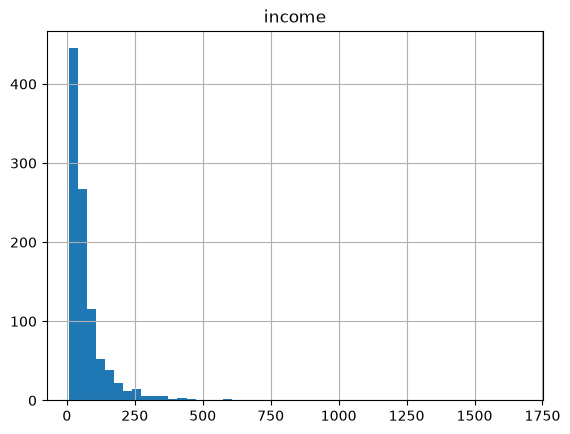

In [54]:
df.hist(column="income", bins=50)

In [55]:
df.columns

Index(['region', 'tenure', 'age', 'marital', 'address', 'income', 'ed',
       'employ', 'retire', 'gender', 'reside', 'custcat'],
      dtype='str')

### normalize data 

***x is tenure and y is churn***

In [60]:
X = df[["region", "tenure", "age", "address", "income", "ed", "employ", "retire", "gender", "reside"]].values 
X[:5]

array([[  2.,  13.,  44.,   9.,  64.,   4.,   5.,   0.,   0.,   2.],
       [  3.,  11.,  33.,   7., 136.,   5.,   5.,   0.,   0.,   6.],
       [  3.,  68.,  52.,  24., 116.,   1.,  29.,   0.,   1.,   2.],
       [  2.,  33.,  33.,  12.,  33.,   2.,   0.,   0.,   1.,   1.],
       [  2.,  23.,  30.,   9.,  30.,   1.,   2.,   0.,   0.,   4.]])

In [61]:
Y = df["custcat"].values
Y[:5]

array([1, 4, 3, 1, 3])

In [66]:
X = preprocessing.StandardScaler().fit(X).transform(X.astype(float))
X[:5]

array([[-0.02696767, -1.055125  ,  0.18450456, -0.25303431, -0.12650641,
         1.0877526 , -0.5941226 , -0.22207644, -1.03459817, -0.23065004],
       [ 1.19883553, -1.14880563, -0.69181243, -0.4514148 ,  0.54644972,
         1.9062271 , -0.5941226 , -0.22207644, -1.03459817,  2.55666158],
       [ 1.19883553,  1.52109247,  0.82182601,  1.23481934,  0.35951747,
        -1.36767088,  1.78752803, -0.22207644,  0.96655883, -0.23065004],
       [-0.02696767, -0.11831864, -0.69181243,  0.04453642, -0.41625141,
        -0.54919639, -1.09029981, -0.22207644,  0.96655883, -0.92747794],
       [-0.02696767, -0.58672182, -0.93080797, -0.25303431, -0.44429125,
        -1.36767088, -0.89182893, -0.22207644, -1.03459817,  1.16300577]])

### split train and test data
#### X
|rows|tenure|
|----|------|
|3|38.0|
#### Y
|rows|churn|
|----|-----|
|3|0.0|

In [67]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=4)

print(x_train[:5])
print("---------------------------------")
print(y_train[:5])
print("---------------------------------")
print(x_test[:5])
print("---------------------------------")
print(y_test[:5])

[[-1.25277087e+00 -1.52352817e+00 -8.51142792e-01 -7.48985528e-01
  -5.09717536e-01  1.08775260e+00 -6.93358040e-01 -2.22076436e-01
  -1.03459817e+00  1.85983368e+00]
 [-2.69676703e-02  2.56403899e-01  3.43834921e-01  2.42916906e-01
  -2.85398826e-01 -5.49196386e-01  1.29006076e-03 -2.22076436e-01
  -1.03459817e+00  1.85983368e+00]
 [-1.25277087e+00 -7.74083089e-01 -6.91812431e-01 -5.46538241e-02
  -5.19064149e-01 -1.36767088e+00 -7.92593483e-01 -2.22076436e-01
  -1.03459817e+00  1.85983368e+00]
 [-2.69676703e-02 -1.52352817e+00 -3.73151707e-01  1.43726663e-01
  -5.00370923e-01 -1.36767088e+00 -7.92593483e-01 -2.22076436e-01
   9.66558833e-01 -9.27477941e-01]
 [ 1.19883553e+00 -2.11999278e-01 -6.12147250e-01 -2.53034311e-01
   2.56704724e-01  1.08775260e+00 -3.95651711e-01 -2.22076436e-01
   9.66558833e-01  1.16300577e+00]]
---------------------------------
[4 4 3 1 3]
---------------------------------
[[-1.25277087e+00 -9.61444360e-01 -9.30807973e-01 -3.52224554e-01
   1.16505530e-01 

In [70]:
from sklearn.neighbors import KNeighborsClassifier

k = 3

neigh = KNeighborsClassifier(k)
neigh.fit(x_train, y_train)
y_hat = neigh.predict(x_test)

print(y_hat[:5])

[1 3 1 4 4]


In [71]:
from sklearn import metrics

metrics.accuracy_score(y_hat, y_test)

0.32

In [73]:
ks = 10
mean_acc = np.zeros((ks-1))
std_acc = np.zeros((ks-1))

for n in range(1, ks):
    neigh = KNeighborsClassifier(n).fit(x_train, y_train)
    y_hat = neigh.predict(x_test)
    mean_acc[n - 1] = metrics.accuracy_score(y_hat, y_test)
    std_acc[n - 1] = np.std(y_hat == y_test)/np.sqrt(y_hat.shape[0])

print(mean_acc)
print(std_acc)

[0.28  0.31  0.32  0.295 0.29  0.31  0.305 0.34  0.33 ]
[0.03174902 0.03270321 0.03298485 0.03224709 0.03208582 0.03270321
 0.03255572 0.03349627 0.03324906]
